# Creación de datos de entrenamiento

## 1. Configuración del entorno

Se configuran las rutas de acceso a los datos generados en la fase de preprocesamiento. Se definen las variables que apuntan a los directorios de imágenes de entrenamiento (`IMAGES_PATH`) y sus correspondientes máscaras de verdad terreno (`MASKS_PATH`) obtenidas del catastro, estableciendo la base para la ingestión de datos por parte de la librería GeoAI.

In [ ]:
import os
import geoai

# Configurar rutas relativas
TRAIN_DATA_PATH = "../data/train"
IMAGES_PATH = f"{TRAIN_DATA_PATH}/images"
MASKS_PATH = f"{TRAIN_DATA_PATH}/masks"

## 2. Comprobación de datos

Se realiza una inspección preliminar de los archivos disponibles en los directorios de entrenamiento. Se listan los ficheros ráster y vectoriales junto con su tamaño en disco, permitiendo verificar que la etapa de preprocesamiento se completó correctamente y que existe una correspondencia uno a uno entre las imágenes y sus máscaras.

In [ ]:
# Mostrar los archivos en las carpetas
print("Capas ráster:")
for i in sorted(os.listdir(IMAGES_PATH)):
    path = os.path.join(IMAGES_PATH, i)
    print(f"  -> {i} | Tamaño: {os.path.getsize(path)/(1024*1024):.2f} MB")

print(f"{'='*60}")

print("Capas vectoriales:")
for i in sorted(os.listdir(MASKS_PATH)):
    path = os.path.join(MASKS_PATH, i)
    print(f"  -> {i} | Tamaño: {os.path.getsize(path)/(1024):.2f} kB")

Capas ráster:
  -> naip_rgb_train_tile1.tif | Tamaño: 3.64 MB
  -> naip_rgb_train_tile2.tif | Tamaño: 4.30 MB
  -> train_2021.tif | Tamaño: 25.86 MB
  -> train_2024.tif | Tamaño: 17.59 MB
Capas vectoriales:
  -> naip_rgb_train_tile1.geojson | Tamaño: 103.60 kB
  -> naip_rgb_train_tile2.geojson | Tamaño: 231.06 kB
  -> train_2021.geojson | Tamaño: 284.68 kB
  -> train_2024.geojson | Tamaño: 211.35 kB


Para confirmar la alineación espacial y la calidad de los datos, se visualiza una muestra aleatoria del conjunto de entrenamiento. Se superpone la máscara vectorial de edificios sobre la ortofoto correspondiente, permitiendo una validación visual rápida de que la máscara coincide con las estructuras visibles en la imagen. Además, el comando cuantifica el número de geometrías (edificios) presentes en la muestra.

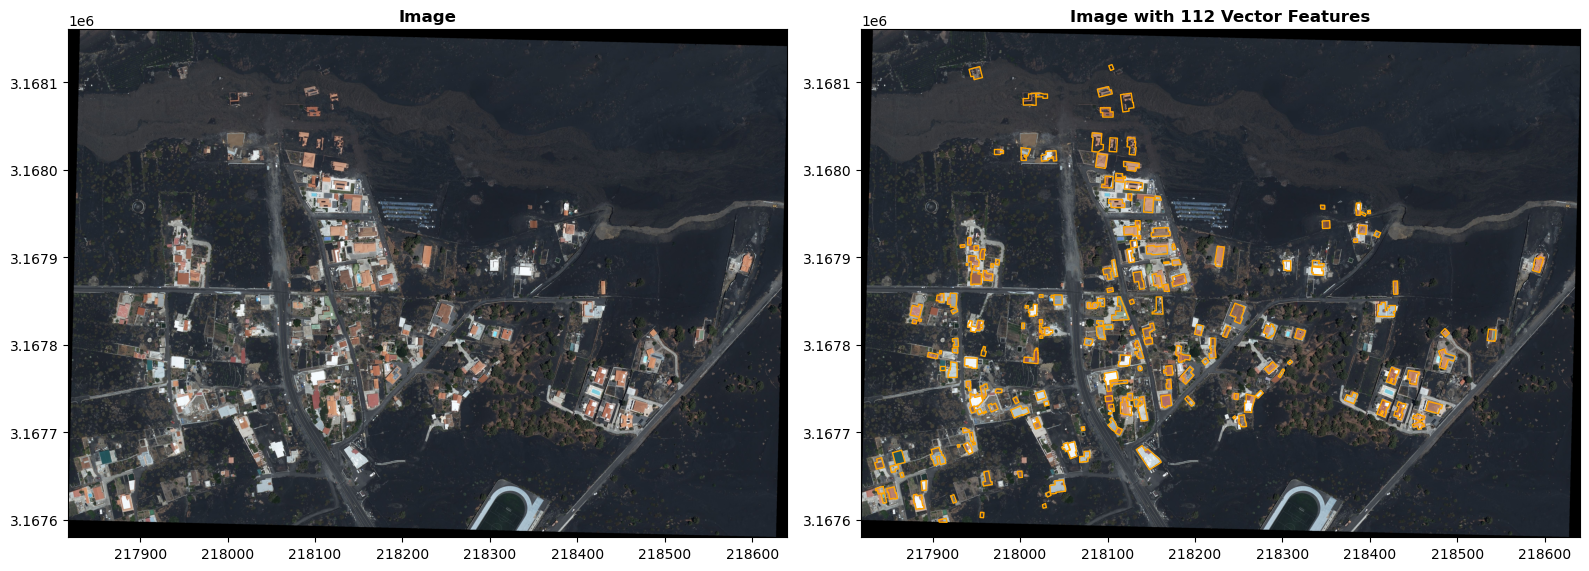


Cantidad de edificios: 112


In [ ]:
# Visualizar uno de los archivos con su vector asociado
image_example = f"{IMAGES_PATH}/train_2024.tif"
mask_example = f"{MASKS_PATH}/train_2024.geojson"
fig, axes, info = geoai.display_image_with_vector(
    image_example, mask_example, vector_color="orange"
)

# Contar los edificios en el área de la imagen
print(f"\n{'='*60}")
print(f"Cantidad de edificios: {info['num_features']}")

## 3. Creación de mosaicos

Se procede a la generación de mosaicos (*tiling*), entradas de tamaño fijo y manejable que GeoAI utiliza en el entrenamiento de modelos (cuaderno `02_creacion_modelo.ipynb`). Se utiliza la función `export_geotiff_tiles_batch` para dividir las áreas de entrenamiento seleccionadas en teselas de 512x512 píxeles. Se aplica un solapamiento (*stride*) de 256 píxeles (50%), lo que incrementa el número de muestras disponibles y mejora la predicción en los bordes de los edificios. El parámetro `skip_empty_tiles=True` optimiza el proceso descartando aquellas teselas que no contienen ninguna edificación.

In [ ]:
# Exportar los mosaicos georreferenciados
stats = geoai.export_geotiff_tiles_batch(
    images_folder=IMAGES_PATH,
    masks_folder=MASKS_PATH,
    output_folder=f"{TRAIN_DATA_PATH}/output",
    tile_size=512,
    stride=256,  # Superposición del 50 % al saltar de mosaico
    class_value_field="class",
    skip_empty_tiles=True,  # Ignora los mosaicos sin edificios
    match_by_name=True,  # Procesa las imagenes y máscaras por nombre de archivo (train_2024.tif = train_2024.geojson)
)

Found 4 matching image-mask pairs to process
Processing batch from ../data/train/images and ../data/train/masks
Output folder: ../data/train/output
------------------------------------------------------------


Processing image pairs:   0%|                                                 | 0/4 [00:00<?, ?it/s]


Processing: naip_rgb_train_tile1
  Image: naip_rgb_train_tile1.tif
  Mask: naip_rgb_train_tile1.geojson


Processing image pairs:  25%|██████████▎                              | 1/4 [00:03<00:09,  3.14s/it]


Processing: naip_rgb_train_tile2
  Image: naip_rgb_train_tile2.tif
  Mask: naip_rgb_train_tile2.geojson


...


Processing: train_2021
  Image: train_2021.tif
  Mask: train_2021.geojson


Processing image pairs:  75%|██████████████████████████████▊          | 3/4 [00:08<00:02,  2.76s/it]


Processing: train_2024
  Image: train_2024.tif
  Mask: train_2024.geojson


Processing image pairs: 100%|█████████████████████████████████████████| 4/4 [00:10<00:00,  2.60s/it]


BATCH PROCESSING SUMMARY
Total image pairs found: 4
Successfully processed: 4
Failed to process: 0
Total tiles generated: 323
Tiles with features: 323
Feature percentage: 100.0%
Output saved to: ../data/train/output
  Images: ../data/train/output/images
  Masks: ../data/train/output/masks
  Annotations: ../data/train/output/annotations


## 4. Revisión de resultados

Finalmente, se despliega una galería con una selección de las teselas generadas. Esto permite verificar que el proceso de recorte ha sido exitoso y que las máscaras binarias (donde los píxeles blancos representan edificios) se han generado correctamente a partir de los vectores originales.

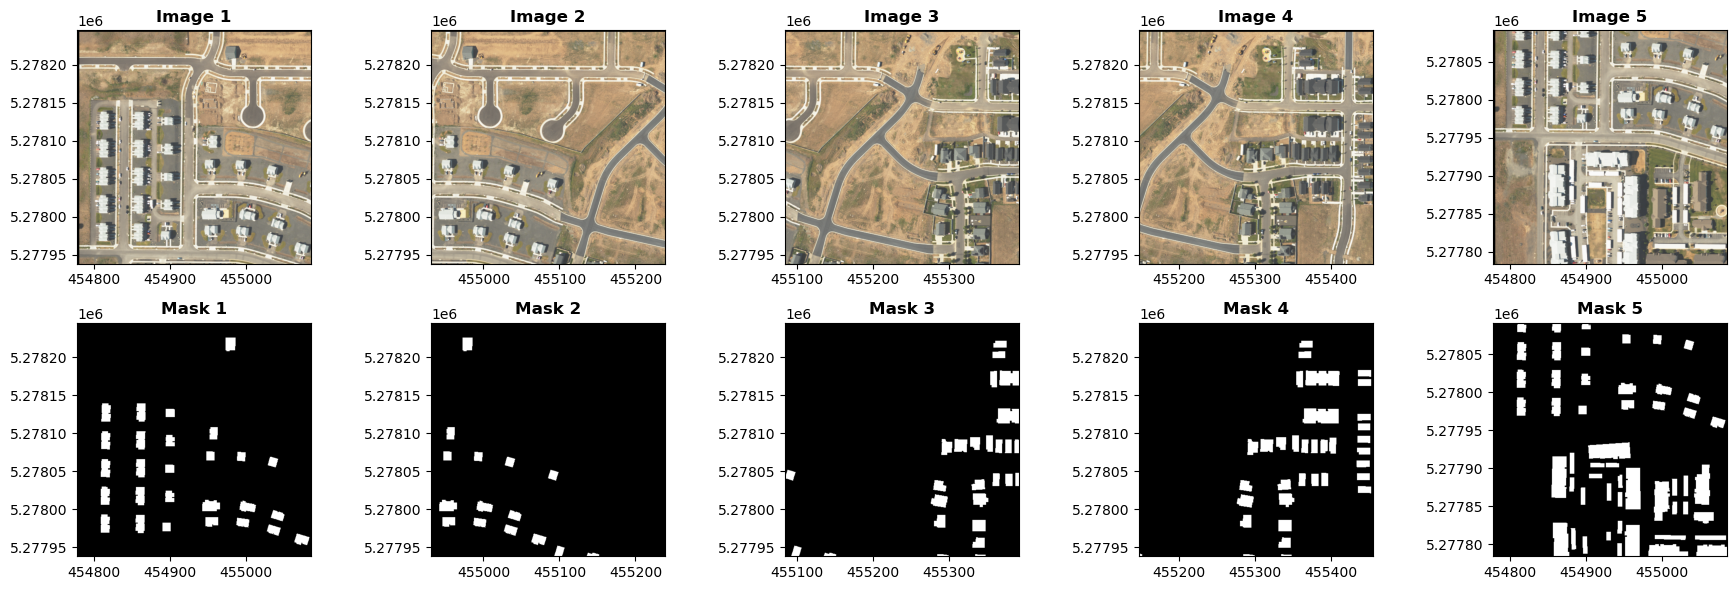

In [ ]:
# Visualizar algunos de los mosaicos generados
output_path = f"{TRAIN_DATA_PATH}/output"
fig = geoai.display_training_tiles(output_path, num_tiles=5)